# Credit Default Risk — Complete EDA
**Project:** Credit Default Risk Modeling  
**Dataset:** German Credit Dataset  
**Goal:** Understand the data, distributions, and relationships before modeling

## 1 Imports & Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2 Load Data

In [4]:
# ── Load your dataset (update path if needed) ──────────────────────────────
data = pd.read_csv('/home/vidit/Public/Project/Customer Churn Prediction/Data/german_credit_data.csv')   # ← change path as needed

print('Shape:', data.shape)
data.head()

Shape: (1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


## 3 Rename Columns (German → English)

In [18]:
column_mapping = {
    'laufkont' : 'checking_account',
    'laufzeit' : 'duration_months',
    'moral'    : 'credit_history',
    'verw'     : 'purpose',
    'hoehe'    : 'credit_amount',
    'sparkont' : 'savings_account',
    'beszeit'  : 'employment_years',
    'rate'     : 'installment_rate',
    'famges'   : 'personal_status',
    'buerge'   : 'other_debtors',
    'wohnzeit' : 'residence_years',
    'verm'     : 'property',
    'alter'    : 'age',
    'weitkred' : 'other_installments',
    'wohn'     : 'housing',
    'bishkred' : 'existing_credits',
    'beruf'    : 'job',
    'pers'     : 'dependents',
    'telef'    : 'telephone',
    'gastarb'  : 'foreign_worker',
    'kredit'   : 'target'
}

data.rename(columns=column_mapping, inplace=True)
print('Columns renamed successfully!')
print(data.columns.tolist())

Columns renamed successfully!
['checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_years', 'installment_rate', 'personal_status', 'other_debtors', 'residence_years', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'target']


## 4 Fix Target Column

**Important:** We need `1 = Default (bad)` and `0 = Good` for all downstream analysis.

The Kaggle version of this dataset uses:
- `1` = Good customer (no default)
- `0` = Bad customer (default)

We flip it so `1 = Default` — this is the **standard ML convention** and required for correct WoE/IV and logistic regression.

In [6]:
# ── Step 1: See what raw values exist ──────────────────────────────────────
print('Raw target value counts:')
print(data['target'].value_counts())
print('Unique values:', sorted(data['target'].unique()))

Raw target value counts:
target
1    700
0    300
Name: count, dtype: int64
Unique values: [np.int64(0), np.int64(1)]


In [19]:
# ── Step 2: Apply the correct mapping based on what you see above ──────────

raw_vals = sorted(data['target'].unique())

if set(raw_vals) == {1, 2}:
    # Original UCI version: 1=Good, 2=Bad
    data['target'] = data['target'].map({1: 0, 2: 1})
    print('Mapping applied: {1→0, 2→1}')

elif set(raw_vals) == {0, 1}:
    # Kaggle version: 1=Good, 0=Bad  →  flip it
    data['target'] = data['target'].map({1: 0, 0: 1})
    print('Mapping applied: {1→0, 0→1}')

else:
    print(f'⚠️  Unexpected values {raw_vals} — check your dataset manually')

# ── Step 3: Verify ─────────────────────────────────────────────────────────
print('\nAfter fix:')
print(data['target'].value_counts())
print(f'\nDefault Rate: {data["target"].mean()*100:.1f}%')
print('Expected: ~30% default rate')

Mapping applied: {1→0, 0→1}

After fix:
target
1    700
0    300
Name: count, dtype: int64

Default Rate: 70.0%
Expected: ~30% default rate


## 5 Basic Data Info

In [8]:
print('=== Shape ===')
print(data.shape)

print('\n=== Data Types ===')
print(data.dtypes)

print('\n=== Missing Values ===')
print(data.isnull().sum())

print('\n=== Descriptive Statistics ===')
data.describe().round(2)

=== Shape ===
(1000, 21)

=== Data Types ===
checking_account      int64
duration_months       int64
credit_history        int64
purpose               int64
credit_amount         int64
savings_account       int64
employment_years      int64
installment_rate      int64
personal_status       int64
other_debtors         int64
residence_years       int64
property              int64
age                   int64
other_installments    int64
housing               int64
existing_credits      int64
job                   int64
dependents            int64
telephone             int64
foreign_worker        int64
target                int64
dtype: object

=== Missing Values ===
checking_account      0
duration_months       0
credit_history        0
purpose               0
credit_amount         0
savings_account       0
employment_years      0
installment_rate      0
personal_status       0
other_debtors         0
residence_years       0
property              0
age                   0
other_installment

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_years,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2.58,20.90,2.54,2.83,3271.25,2.10,3.38,2.97,2.68,1.14,...,2.36,35.54,2.68,1.93,1.41,2.90,1.84,1.40,1.96,0.30
std,1.26,12.06,1.08,2.74,2822.75,1.58,1.21,1.12,0.71,0.48,...,1.05,11.35,0.71,0.53,0.58,0.65,0.36,0.49,0.19,0.46
min,1.00,4.00,0.00,0.00,250.00,1.00,1.00,1.00,1.00,1.00,...,1.00,19.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00
25%,1.00,12.00,2.00,1.00,1365.50,1.00,3.00,2.00,2.00,1.00,...,1.00,27.00,3.00,2.00,1.00,3.00,2.00,1.00,2.00,0.00
50%,2.00,18.00,2.00,2.00,2319.50,1.00,3.00,3.00,3.00,1.00,...,2.00,33.00,3.00,2.00,1.00,3.00,2.00,1.00,2.00,0.00
75%,4.00,24.00,4.00,3.00,3972.25,3.00,5.00,4.00,3.00,1.00,...,3.00,42.00,3.00,2.00,2.00,3.00,2.00,2.00,2.00,1.00
max,4.00,72.00,4.00,10.00,18424.00,5.00,5.00,4.00,4.00,3.00,...,4.00,75.00,3.00,3.00,4.00,4.00,2.00,2.00,2.00,1.00


## 6 Define Feature Groups

Even though all columns are `int64`, many are **ordinal categories** (coded as numbers), not true continuous variables. We must separate them.

In [9]:
numeric_cols = [
    'duration_months', 'credit_amount', 'age',
    'installment_rate', 'residence_years',
    'existing_credits', 'dependents'
]

categorical_cols = [
    'checking_account', 'credit_history', 'purpose',
    'savings_account', 'employment_years', 'personal_status',
    'other_debtors', 'property', 'other_installments',
    'housing', 'job', 'telephone', 'foreign_worker'
]

print(f'Numeric features   : {len(numeric_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

Numeric features   : 7
Categorical features: 13


## 7 Target Distribution

**Observation:** ~30% default rate = class imbalance. We'll handle this during modeling with class weights or SMOTE.

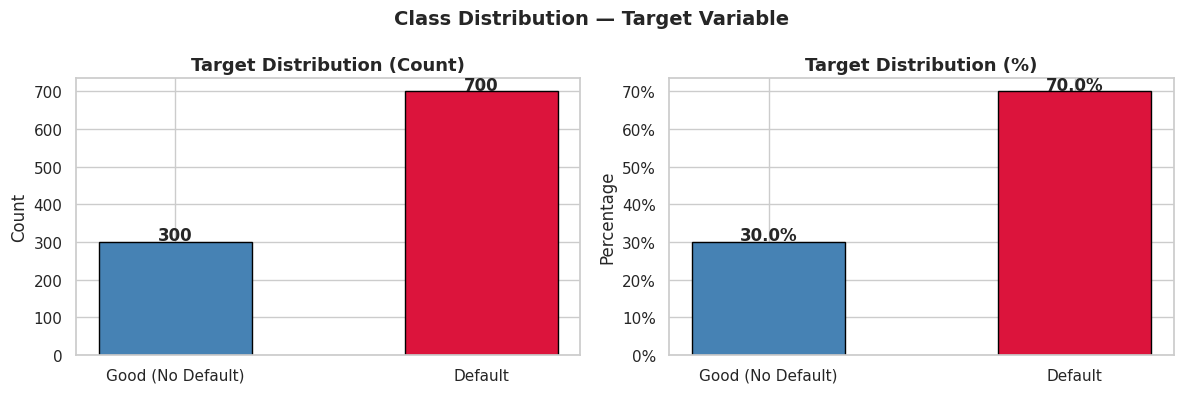

Default Rate: 70.0%
!! Class imbalance present — will handle during modeling


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = data['target'].value_counts().sort_index()
bar_labels = ['Good (No Default)', 'Default']
colors = ['steelblue', 'crimson']

# Count plot
bars = axes[0].bar(bar_labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Target Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Percentage plot
pcts = (counts / counts.sum() * 100).values
bars2 = axes[1].bar(bar_labels, pcts, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Target Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars2, pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Class Distribution — Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Default Rate: {data["target"].mean()*100:.1f}%')
print('!! Class imbalance present — will handle during modeling')

## 8 Numeric Feature Distributions

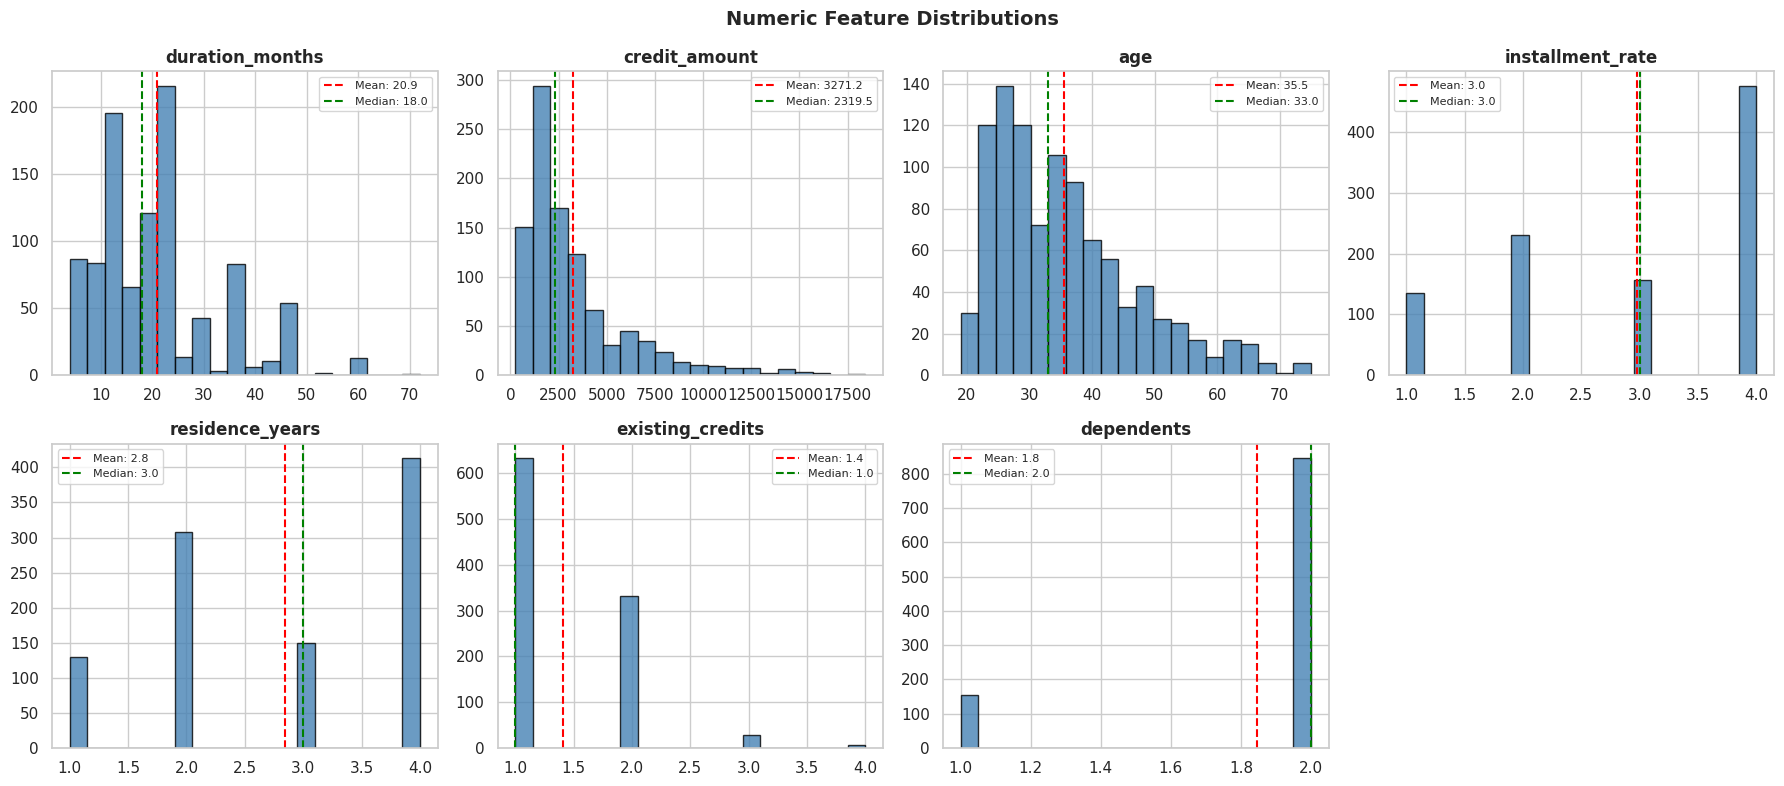

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].axvline(data[col].mean(), color='red', linestyle='--', label=f'Mean: {data[col].mean():.1f}')
    axes[i].axvline(data[col].median(), color='green', linestyle='--', label=f'Median: {data[col].median():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9 Boxplots — Numeric Features vs Default Status

**Key question:** Do defaulters look different from non-defaulters on numeric features?

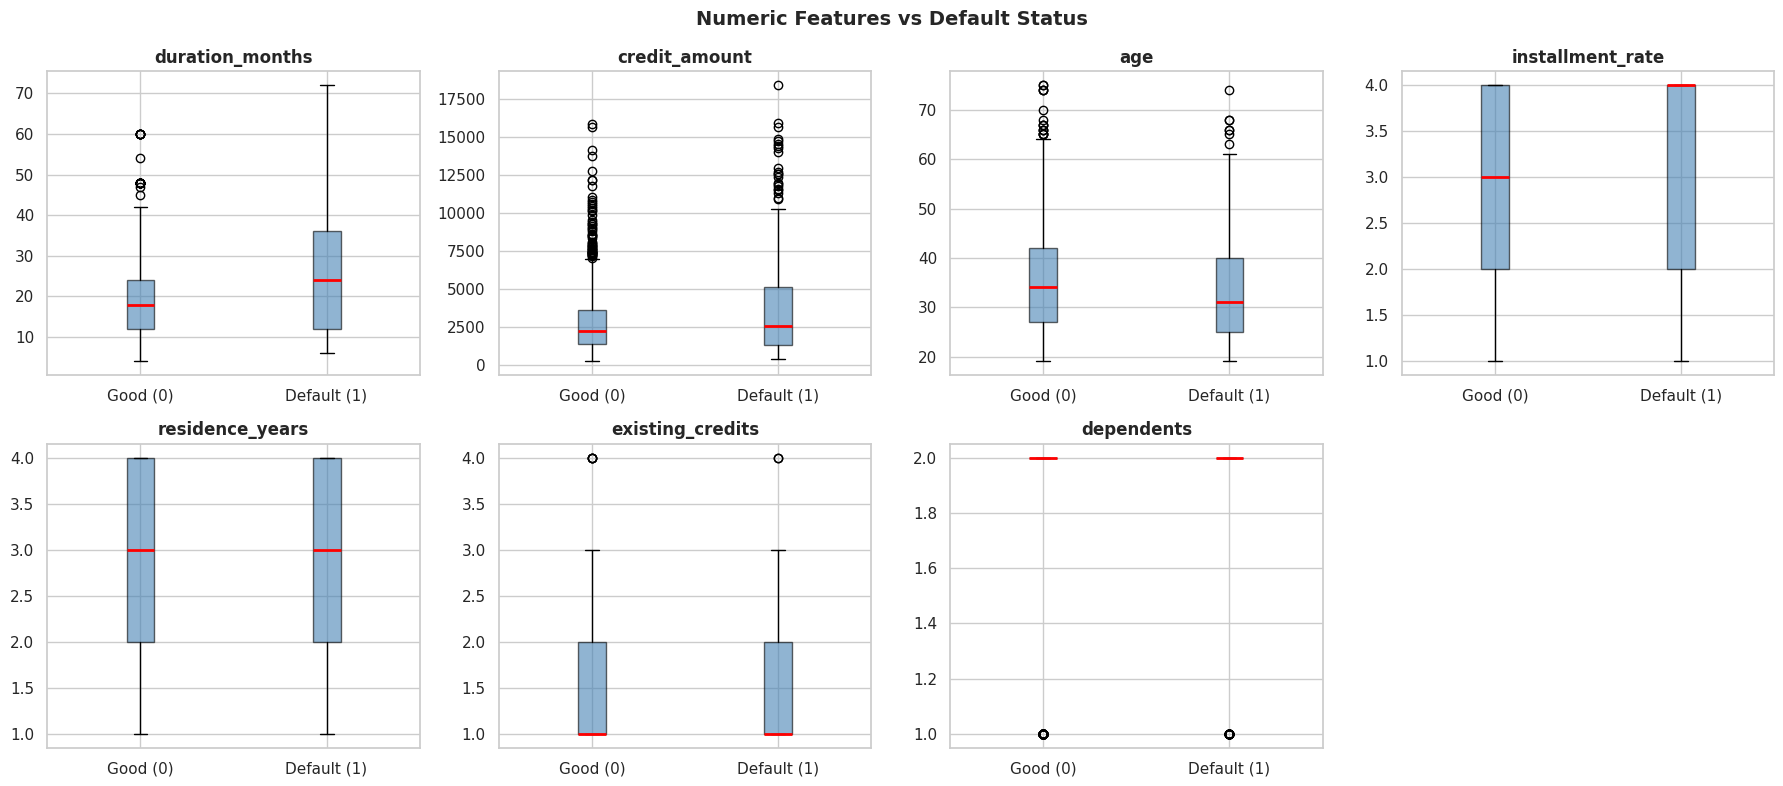

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    good   = data[data['target'] == 0][col]
    bad    = data[data['target'] == 1][col]
    axes[i].boxplot([good, bad], labels=['Good (0)', 'Default (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')

axes[-1].set_visible(False)

plt.suptitle('Numeric Features vs Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10 Default Rate by Categorical Features

This is the **most important EDA chart** for credit risk — shows which categories have higher default rates.

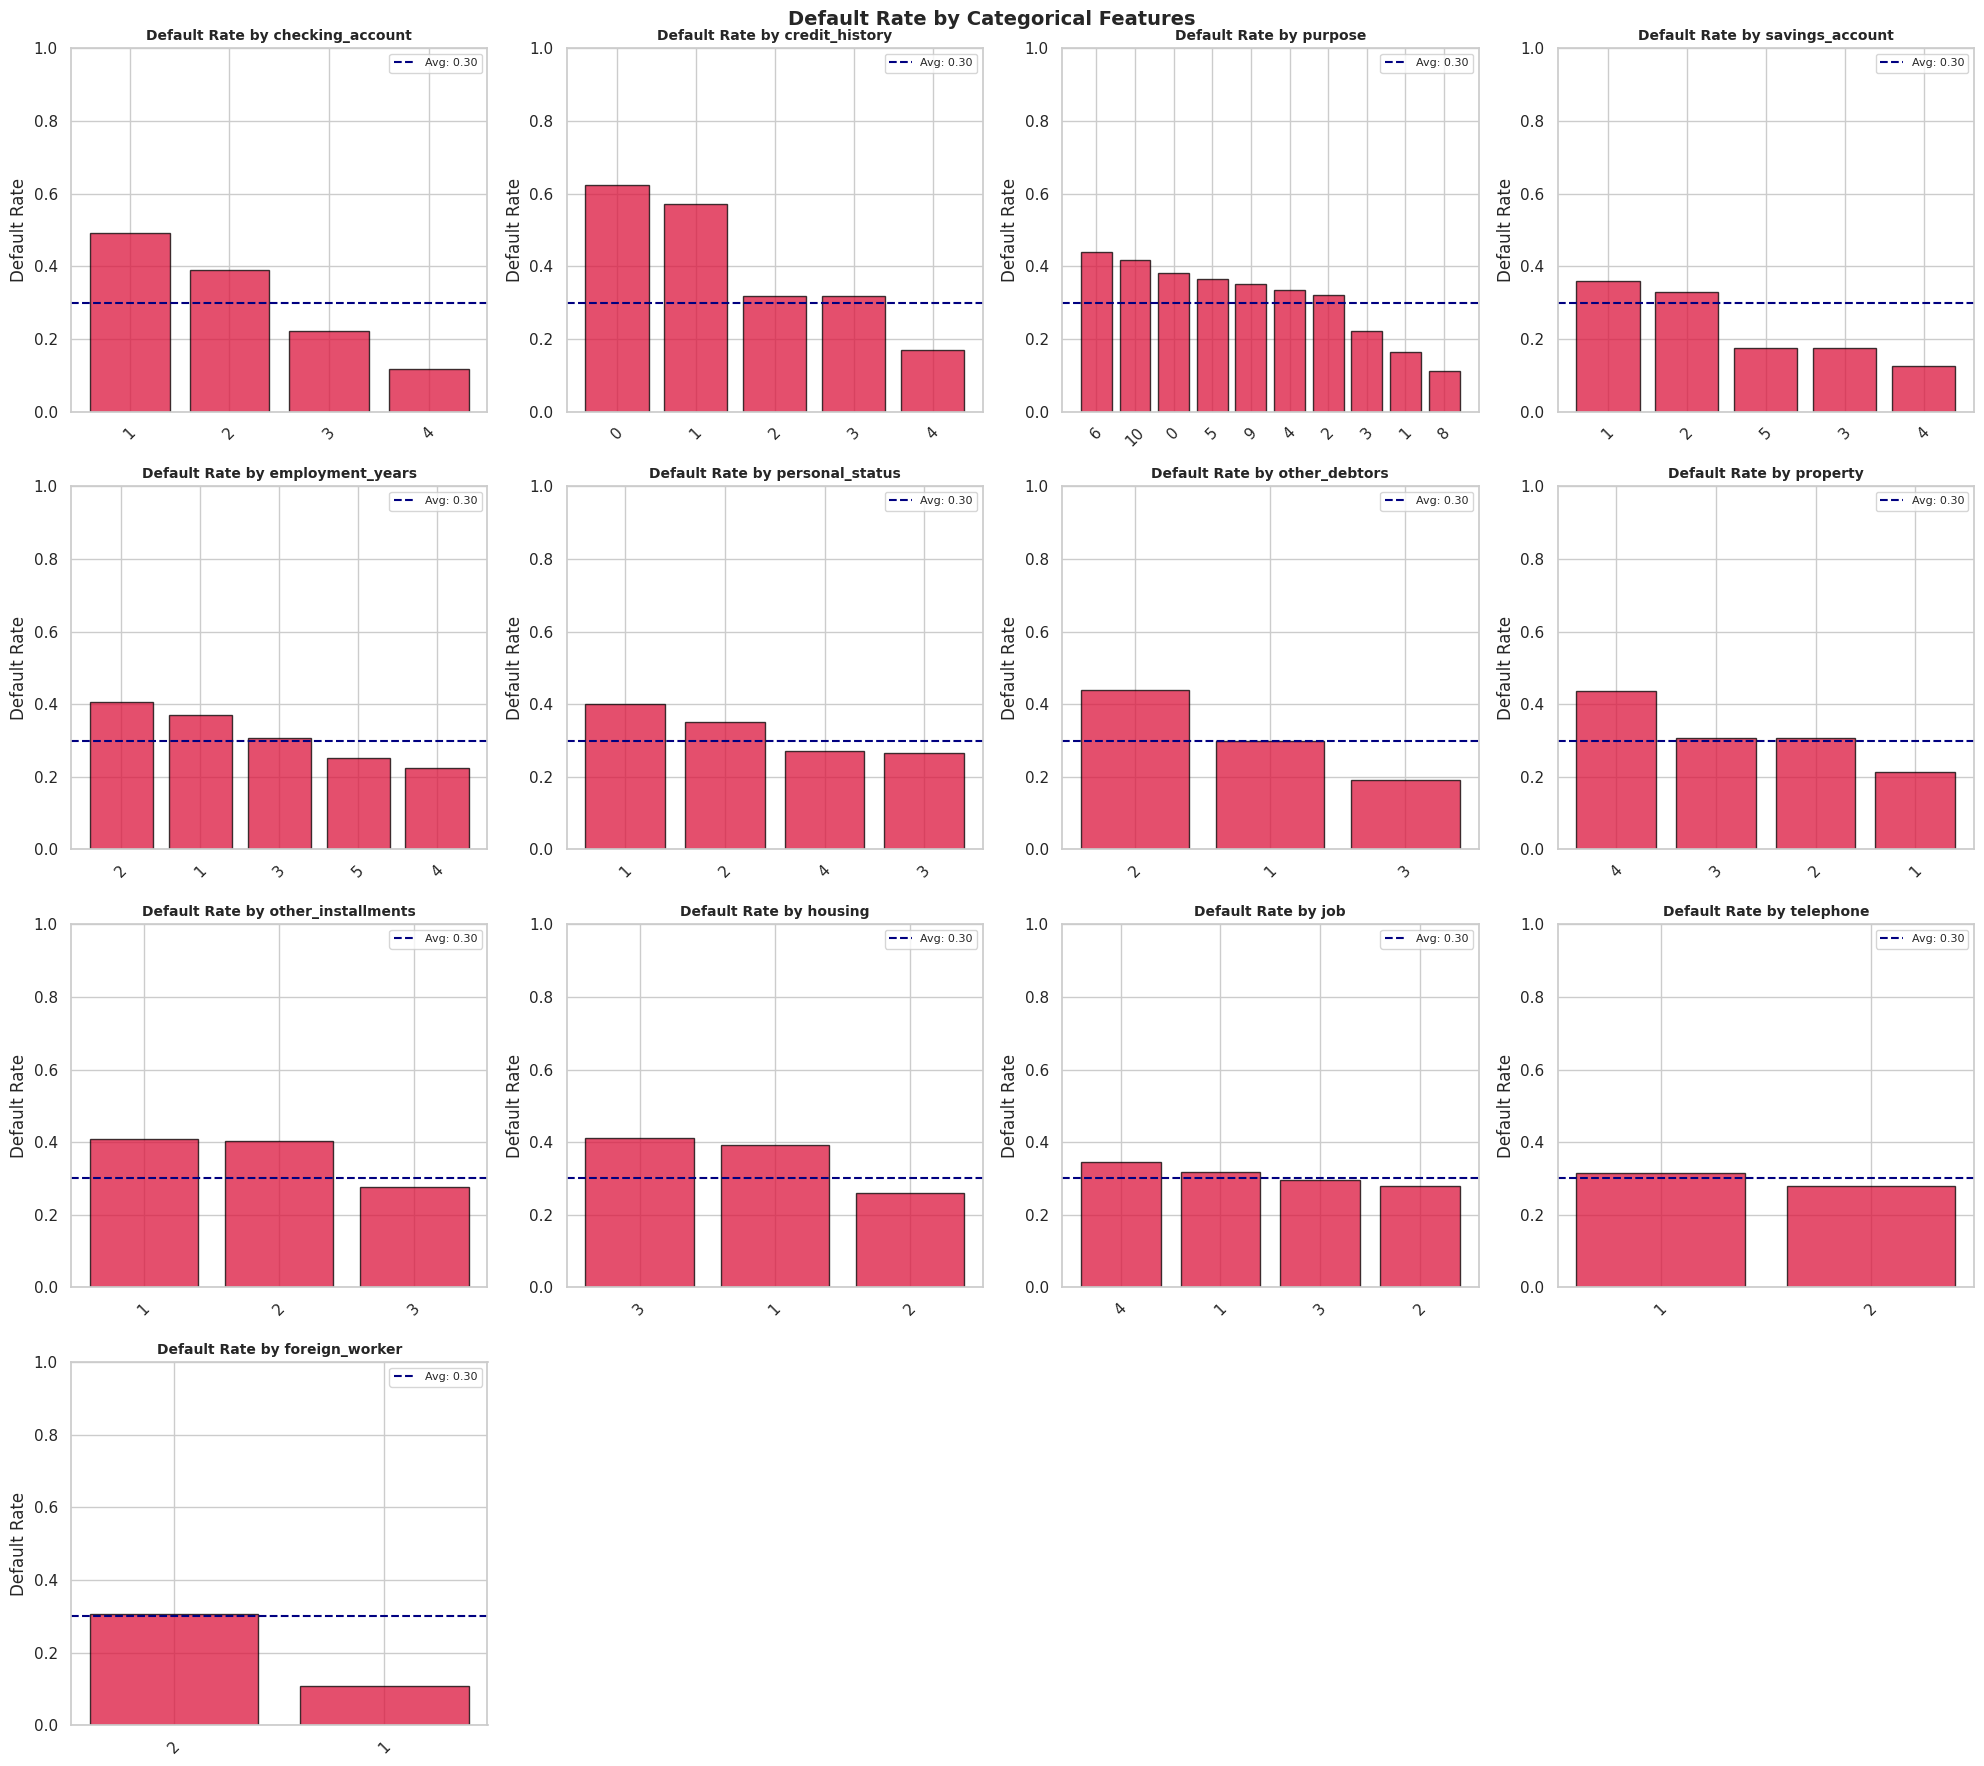

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    default_rate = data.groupby(col)['target'].mean().sort_values(ascending=False)
    bars = axes[i].bar(default_rate.index.astype(str), default_rate.values,
                       color='crimson', alpha=0.75, edgecolor='black')
    axes[i].axhline(data['target'].mean(), color='navy', linestyle='--',
                    linewidth=1.5, label=f'Avg: {data["target"].mean():.2f}')
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Default Rate')
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11 Correlation Heatmap

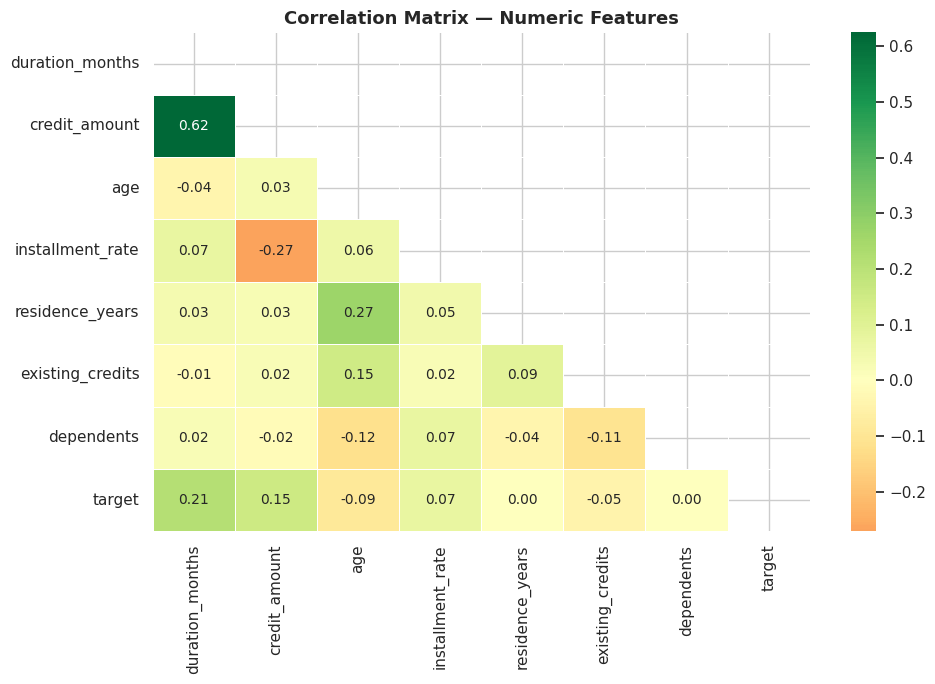

In [14]:
plt.figure(figsize=(10, 7))
corr = data[numeric_cols + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12 Outlier Detection — IQR Method

In [22]:
print('=== Outlier Detection (IQR Method) ===\n')

outlier_summary = []
for col in numeric_cols:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    pct = n_outliers / len(data) * 100
    outlier_summary.append({'Feature': col, 'Lower Bound': round(lower,2),
                             'Upper Bound': round(upper,2),
                             'Outliers': n_outliers, 'Outlier %': round(pct,2)})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))
print('\n!!  High outlier % features need attention before modeling')

=== Outlier Detection (IQR Method) ===

         Feature  Lower Bound  Upper Bound  Outliers  Outlier %
 duration_months        -6.00        42.00        70        7.0
   credit_amount     -2544.62      7882.38        72        7.2
             age         4.50        64.50        23        2.3
installment_rate        -1.00         7.00         0        0.0
 residence_years        -1.00         7.00         0        0.0
existing_credits        -0.50         3.50         6        0.6
      dependents         2.00         2.00       155       15.5

!!  High outlier % features need attention before modeling


## 13 Summary Statistics by Target

In [16]:
print('=== Mean Values: Good vs Default ===\n')
summary = data.groupby('target')[numeric_cols].mean().round(2)
summary.index = ['Good (0)', 'Default (1)']
print(summary.T.to_string())

print('\n=== Difference (Default - Good) ===')
diff = (summary.loc['Default (1)'] - summary.loc['Good (0)']).round(2)
print(diff.to_string())

=== Mean Values: Good vs Default ===

                  Good (0)  Default (1)
duration_months      19.21        24.86
credit_amount      2985.44      3938.13
age                  36.22        33.96
installment_rate      2.92         3.10
residence_years       2.84         2.85
existing_credits      1.42         1.37
dependents            1.84         1.85

=== Difference (Default - Good) ===
duration_months       5.65
credit_amount       952.69
age                  -2.26
installment_rate      0.18
residence_years       0.01
existing_credits     -0.05
dependents            0.01


## 14 EDA Summary & Key Findings

**Dataset:**
- 1,000 rows, 21 features (7 numeric, 13 categorical, 1 target)
- No missing values
- Default rate: ~30% → class imbalance present

**Key Observations:**
- `checking_account` shows the highest variation in default rate across categories
- `credit_amount` and `duration_months` are higher on average for defaulters
- `age` is lower on average for defaulters — younger applicants default more
- `credit_history` is a strong predictor based on default rate by category

**Next Steps:**
- Phase 1: WoE + IV analysis to quantify feature predictive power
- Phase 2: Hypothesis testing to statistically confirm these observations